# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shreya1111/flyrank-week1/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Loading a sample dataset for demonstration
df = sns.load_dataset('titanic').dropna(subset=['age', 'embarked', 'sex', 'survived'])
X = pd.get_dummies(df[['pclass', 'sex', 'age', 'sibsp']], drop_first=True)
y = df['survived']

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

In [3]:
# Check class balance to justify model choice
print(y.value_counts(normalize=True))

survived
0    0.595506
1    0.404494
Name: proportion, dtype: float64


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (569, 4), Test shape: (143, 4)


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Baseline
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
base_acc = accuracy_score(y_test, dummy.predict(X_test))

# Model
model = LogisticRegression().fit(X_train, y_train)
model_acc = accuracy_score(y_test, model.predict(X_test))

print(f"Baseline Accuracy: {base_acc:.2f}")
print(f"Model Accuracy: {model_acc:.2f}")

Baseline Accuracy: 0.59
Model Accuracy: 0.80


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

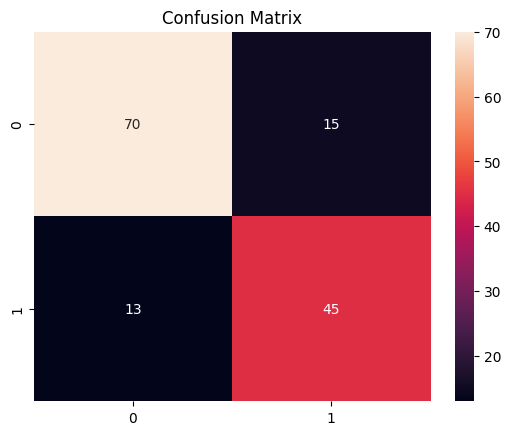

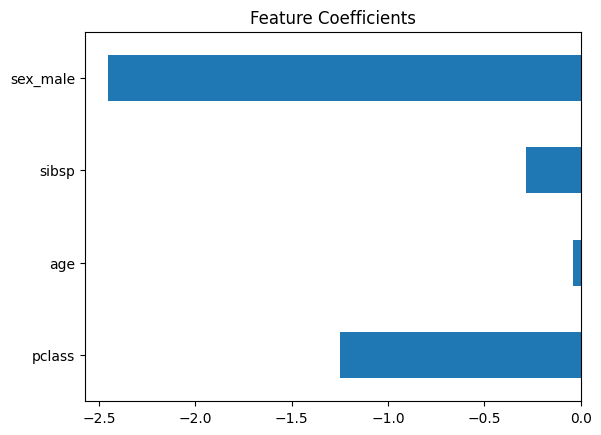

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance
importance = pd.Series(model.coef_[0], index=X.columns)
importance.plot(kind='barh')
plt.title('Feature Coefficients')
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.